In [4]:
import numpy as np
import matplotlib.pyplot as plt

house_size = np.array([50, 60, 70, 80, 90, 100, 110, 120])
rooms      = np.array([1, 2, 2, 3, 3, 4, 4, 5])
price      = np.array([160, 170, 220, 230, 280, 290, 350, 340])

a = np.array([1, 2, 3, 4, 5])
print("Array:", a)
print("Shape:", a.shape)
print("Mean:", np.mean(a))
print("Std:", np.std(a))

Array: [1 2 3 4 5]
Shape: (5,)
Mean: 3.0
Std: 1.4142135623730951


2D array

In [ ]:
data = np.array([[1, 2],
                 [3, 4],
                 [5, 6]])

print("Array:\n", data)
print("Shape:", data.shape)
print("Mean of each column:", np.mean(data, axis=0))
print("Dot product test:", np.dot([1,2,3], [4,5,6]))

Array:
 [[1 2]
 [3 4]
 [5 6]]
Shape: (3, 2)
Mean of each column: [3. 4.]
Dot product test: 32


Dataset: house size vs price

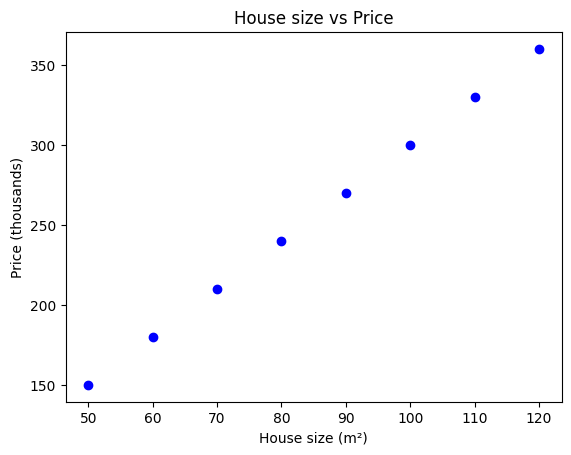

In [ ]:
import matplotlib.pyplot as plt

house_size = np.array([50, 60, 70, 80, 90, 100, 110, 120])
price      = np.array([150, 180, 210, 240, 270, 300, 330, 360])

# scatter plot
plt.scatter(house_size, price, color='blue')
plt.xlabel("House size (m²)")
plt.ylabel("Price (thousands)")
plt.title("House size vs Price")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

house_size = np.array([50, 60, 70, 80, 90, 100, 110, 120])
price      = np.array([150, 180, 210, 240, 270, 300, 330, 360])

First model

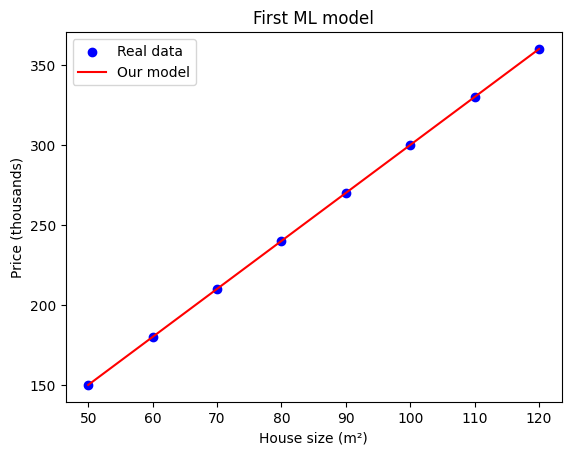

Real prices:       [150 180 210 240 270 300 330 360]
Predicted prices:  [150 180 210 240 270 300 330 360]


In [ ]:
w = 3
b = 0

# Calculate predictions
predictions = w * house_size + b


plt.scatter(house_size, price, color='blue', label='Real data')
plt.plot(house_size, predictions, color='red', label='Our model')
plt.xlabel("House size (m²)")
plt.ylabel("Price (thousands)")
plt.title("First ML model")
plt.legend()
plt.show()

print("Real prices:      ", price)
print("Predicted prices: ", predictions)

trying with messy data with a real world example

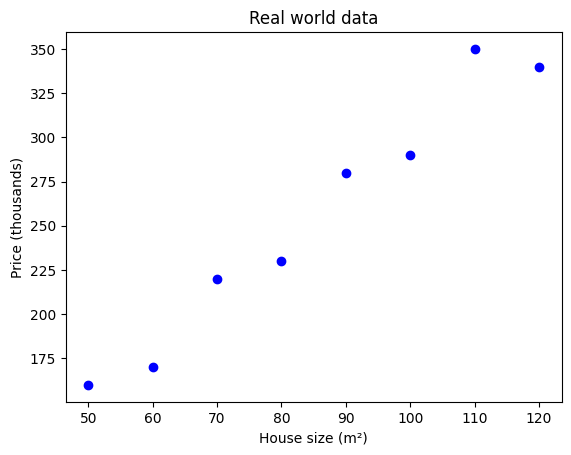

In [ ]:
house_size = np.array([50, 60, 70, 80, 90, 100, 110, 120])
price      = np.array([160, 170, 220, 230, 280, 290, 350, 340])


plt.scatter(house_size, price, color='blue')
plt.xlabel("House size (m²)")
plt.ylabel("Price (thousands)")
plt.title("Real world data")
plt.show()

The process of measuring error and adjusting is **gradient descent**.

In [ ]:
# starting with random guess
w = 0.0
b = 0.0
learning_rate = 0.0001
iterations = 1000
n = len(house_size)

# gradient descent loop
for i in range(iterations):
    predictions = w * house_size + b
    error = predictions - price

    # adjust w and b
    w = w - learning_rate * (1/n) * np.dot(error, house_size)
    b = b - learning_rate * (1/n) * np.sum(error)

    # printing progress
    if i % 200 == 0:
        loss = (1/(2*n)) * np.sum(error**2)
        print(f"Iteration {i}: w={w:.2f}, b={b:.2f}, loss={loss:.2f}")

print(f"\nFinal: w={w:.2f}, b={b:.2f}")

Iteration 0: w=2.32, b=0.03, loss=34775.00
Iteration 200: w=2.99, b=0.05, loss=87.22
Iteration 400: w=2.99, b=0.06, loss=87.21
Iteration 600: w=2.99, b=0.07, loss=87.20
Iteration 800: w=2.99, b=0.09, loss=87.19

Final: w=2.99, b=0.10


Final cell to visualize the result

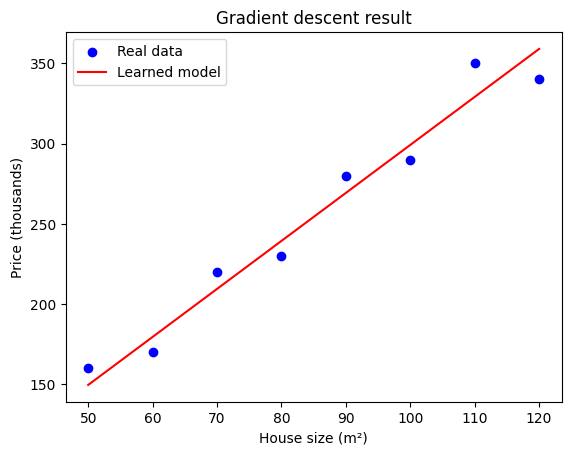

In [ ]:
predictions = w * house_size + b

plt.scatter(house_size, price, color='blue', label='Real data')
plt.plot(house_size, predictions, color='red', label='Learned model')
plt.xlabel("House size (m²)")
plt.ylabel("Price (thousands)")
plt.title("Gradient descent result")
plt.legend()
plt.show()

Today I learned that in real world data you cannot just guess the model parameters manually because the data is messy and scattered. So instead I used gradient descent, an algorithm that starts with a random guess for w and b, measures how wrong the prediction is using a loss function, then slowly adjusts w and b in the right direction to reduce that error. After 1000 iterations the loss dropped from 34,775 to 87 and the model learned on its own that w should be around 3.

This process of measuring error and adjusting is the core of how every machine learning model learns, from simple linear regression all the way to neural networks.

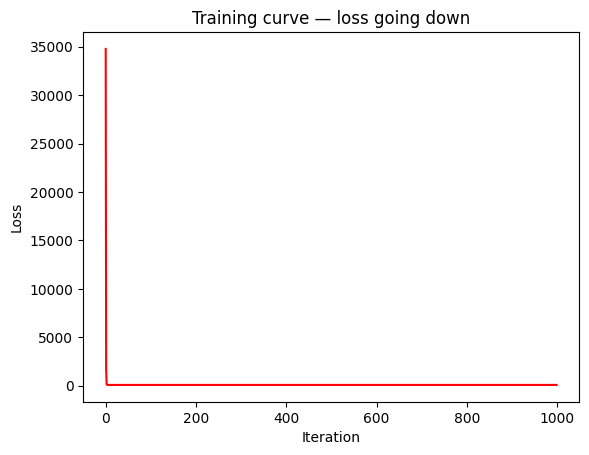

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

house_size = np.array([50, 60, 70, 80, 90, 100, 110, 120])
price      = np.array([160, 170, 220, 230, 280, 290, 350, 340])

# store loss at every iteration
w = 0.0
b = 0.0
learning_rate = 0.0001
iterations = 1000
n = len(house_size)
loss_history = []

for i in range(iterations):
    predictions = w * house_size + b
    error = predictions - price

    w = w - learning_rate * (1/n) * np.dot(error, house_size)
    b = b - learning_rate * (1/n) * np.sum(error)

    loss = (1/(2*n)) * np.sum(error**2)
    loss_history.append(loss)


plt.plot(loss_history, color='red')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training curve — loss going down")
plt.show()

Plotting how the loss goes down over every iteration. That's called a **training curve**.

The loss drops sharply in the first 200 iterations as gradient descent
finds the right direction. After that it flattens. The model has converged
and found the best possible w and b for this data.

 **Multiple features + feature scaling**

When your dataset has multiple features with different scales, you standardize them by subtracting the mean and divide by std, so gradient descent treats all features fairly.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# dataset with 2 features
house_size = np.array([50, 60, 70, 80, 90, 100, 110, 120])
rooms      = np.array([1, 2, 2, 3, 3, 4, 4, 5])
price      = np.array([160, 170, 220, 230, 280, 290, 350, 340])


print("Before scaling:")
print("House size mean:", np.mean(house_size), "std:", np.std(house_size))
print("Rooms mean:", np.mean(rooms), "std:", np.std(rooms))

Before scaling:
House size mean: 85.0 std: 22.9128784747792
Rooms mean: 3.0 std: 1.224744871391589


In [6]:
# standardize both features
house_size_scaled = (house_size - np.mean(house_size)) / np.std(house_size)
rooms_scaled = (rooms - np.mean(rooms)) / np.std(rooms)

print("After scaling:")
print("House size:", np.round(house_size_scaled, 2))
print("Rooms:     ", np.round(rooms_scaled, 2))
print("\nHouse size mean:", np.round(np.mean(house_size_scaled), 2), "std:", np.round(np.std(house_size_scaled), 2))
print("Rooms mean:", np.round(np.mean(rooms_scaled), 2), "std:", np.round(np.std(rooms_scaled), 2))

After scaling:
House size: [-1.53 -1.09 -0.65 -0.22  0.22  0.65  1.09  1.53]
Rooms:      [-1.63 -0.82 -0.82  0.    0.    0.82  0.82  1.63]

House size mean: 0.0 std: 1.0
Rooms mean: 0.0 std: 1.0


Both features now have exactly the same scale. Gradient descent will treat them fairly.

Dataset shape: (8, 2)
Final weights: w=[49.4  15.39], b=254.99
Final loss: 127.09


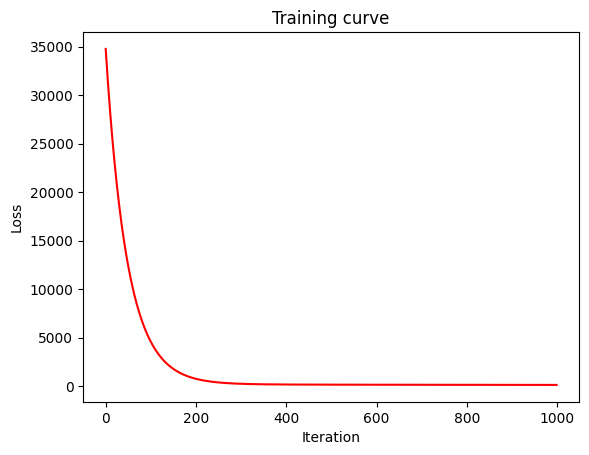

In [7]:
X = np.column_stack([house_size_scaled, rooms_scaled])
print("Dataset shape:", X.shape)

# gradient descent with 2 features
w = np.zeros(2)  # one weight per feature
b = 0.0
learning_rate = 0.01
iterations = 1000
n = len(price)
loss_history = []

for i in range(iterations):
    predictions = np.dot(X, w) + b
    error = predictions - price

    w = w - learning_rate * (1/n) * np.dot(X.T, error)
    b = b - learning_rate * (1/n) * np.sum(error)

    loss = (1/(2*n)) * np.sum(error**2)
    loss_history.append(loss)

print(f"Final weights: w={np.round(w, 2)}, b={b:.2f}")
print(f"Final loss: {loss_history[-1]:.2f}")

# plot training curve
plt.plot(loss_history, color='red')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training curve")
plt.show()

With multiple features, gradient descent learns one weight per feature, the bigger the weight, the more that feature influences the prediction.

Learning outcomes:

*   Real datasets have many features not just one.
*   Features with big numbers dominate gradient descent unfairly.
*   The weights tell you which features matter most.
*   After scaling both features had mean 0 and std 1.




